In [1]:
import torch
import warnings
import sys
import os
import math
warnings.filterwarnings("ignore")
sys.path.insert(0, '/u/yse2/deepdisc/configs')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from deepdisc.data_format.register_data import register_data_set
from detectron2.data import DatasetCatalog, MetadataCatalog
from detectron2.config import LazyConfig, instantiate
from detectron2.checkpoint import DetectionCheckpointer
from detectron2.utils.events import EventStorage

from deepdisc.model.loaders import return_train_loader, return_test_loader
from custom.mappers import FileNameWCSMapper, ResizeCombinedMaskedRomanMapper, ResizeCombinedTestMapper

from astropy.visualization import make_lupton_rgb
from deepdisc.astrodet.visualizer import Visualizer, ColorMode
from deepdisc.utils.norms import asinh_norm
from detectron2.structures import Instances

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from captum.attr import FeatureAblation

# Config and Data Setup

In [4]:
data_root_dir = os.path.expanduser('~/lsst_data/')
anns_folder = 'annotations_lvl5'
MAPPER_REGISTRY = {
    "standard_30k": FileNameWCSMapper,
    "standard_pad_30k": FileNameWCSMapper,
    "standard_all": FileNameWCSMapper,
    "comb_30k": ResizeCombinedTestMapper, # ResizeCombinedMaskedRomanMapper, #ResizeCombinedTestMapper
}
MODEL_DEFAULTS = {
    "standard_30k": {
        "cfgfile":      "/u/yse2/deepdisc/configs/solo/swin_lsst_30k.py",
        "run_name":     "lsst5_30k_4h200_bs192_ep50",
        "eval_data_fn": f"{data_root_dir}{anns_folder}/val_4k_keypoints.json",
        "test_data_fn": f"{data_root_dir}{anns_folder}/test_8k_keypoints.json",
    },
    "standard_pad_30k": {
        "cfgfile":      "/u/yse2/deepdisc/configs/solo/swin_lsst_30k_pad.py",
        "run_name":     "lsst5_pad_30k_4h200_bs192_ep50",
        "eval_data_fn": f"{data_root_dir}{anns_folder}/val_4k_keypoints.json",
        "test_data_fn": f"{data_root_dir}{anns_folder}/test_8k_keypoints.json",
    },
    "standard_all": {
        "cfgfile":      "/u/yse2/deepdisc/configs/solo/swin_lsst_100k.py",
        "run_name":     "lsst5_all_4h200_bs192_ep20",
        "eval_data_fn": f"{data_root_dir}{anns_folder}/val_keypoints.json",
        "test_data_fn": f"{data_root_dir}{anns_folder}/test_keypoints.json",
    },
    "comb_30k": {
        "cfgfile":      "/u/yse2/deepdisc/configs/solo/swin_comb_lsst_roman_30k.py",
        "run_name":     "comb_30k_4h200_bs144_ep50",
        "eval_data_fn": f"{data_root_dir}{anns_folder}/val_4k_keypoints_wcs.json",
        "test_data_fn": f"{data_root_dir}{anns_folder}/test_8k_keypoints_wcs.json",
    }
}

model_type = "standard_pad_30k" # options: standard_30k, standard_pad_30k, standard_all, clip_30k, clip_all
defaults = MODEL_DEFAULTS[model_type]
cfgfile = None
run_name = None
test_data_fn = None
data_split = 'eval'
if cfgfile is None:
    cfgfile = defaults["cfgfile"]
if run_name is None:
    run_name = defaults["run_name"]
if test_data_fn is None:
    if data_split == 'eval':
        test_data_fn = defaults["eval_data_fn"]
    else:
        test_data_fn = defaults["test_data_fn"]
base_run_dir = os.path.expanduser('~/lsst_runs/')
run_dir = f'{base_run_dir}{run_name}'
model_path = f'{run_dir}/{run_name}.pth'
# model_path = f"/projects/bdsp/yse2/cascade_mask_rcnn_swin_b_in21k_clip_roman_rubin_model.pkl"
print(f"Using config file {cfgfile}")
print(f"Using model from {model_path}")
print(f"Using data from {test_data_fn}")

Using config file /u/yse2/deepdisc/configs/solo/swin_lsst_30k_pad.py
Using model from /u/yse2/lsst_runs/lsst5_pad_30k_4h200_bs192_ep50/lsst5_pad_30k_4h200_bs192_ep50.pth
Using data from /u/yse2/lsst_data/annotations_lvl5/val_4k_keypoints.json


In [7]:
test_data = pd.read_json(test_data_fn)
print(f"Loaded test data from {test_data_fn} with {len(test_data)} images.")
cfg = LazyConfig.load(cfgfile) # using a Swin Transformer
for key in cfg.get("MISC", dict()).keys():
    cfg[key] = cfg.MISC[key]
cfg.DATASETS.TEST = "test"
cfg.dataloader.augs = None # no augs for test set since we want preds on OG images
cfg.dataloader.test.mapper = MAPPER_REGISTRY[model_type]
cfg.dataloader.test.total_batch_size = 2
cfg.train.init_checkpoint = model_path
print(f"Config loaded successfully!")
print(f"Registering test dataset from: {test_data_fn}")
try:
    DatasetCatalog.remove(cfg.DATASETS.TEST)
    MetadataCatalog.remove(cfg.DATASETS.TEST)
except:
    pass
custom_colors = [
    (0, 255, 0),    # green for galaxies
    (0, 0, 255),    # blue for stars
]
astrotest_metadata = register_data_set(
    cfg.DATASETS.TEST, test_data_fn, thing_classes=cfg.metadata.classes, thing_colors=custom_colors
)
print(f"Batch size (across all GPUs): {cfg.dataloader.test.total_batch_size}")
print(f"Steps per epoch: {cfg.dataloader.steps_per_epoch}")
print(f"Pixel mean: {cfg.model.pixel_mean[:3]}...")
print(f"Pixel std: {cfg.model.pixel_std[:3]}...")  

Loaded test data from /u/yse2/lsst_data/annotations_lvl5/val_4k_keypoints.json with 4285 images.
Config loaded successfully!
Registering test dataset from: /u/yse2/lsst_data/annotations_lvl5/val_4k_keypoints.json
Batch size (across all GPUs): 2
Steps per epoch: 156
Pixel mean: [0.05976010245856449, 0.056551213257199154, 0.0807974308255675]...
Pixel std: [8.551560965881256, 3.2360131344242697, 3.999492200138785]...


In [ ]:
# print(f"Registering training dataset from: {train_file}")
# try:
#     DatasetCatalog.remove(cfg.DATASETS.TRAIN)
#     MetadataCatalog.remove(cfg.DATASETS.TRAIN)
#     DatasetCatalog.remove(cfg.DATASETS.TEST)
#     MetadataCatalog.remove(cfg.DATASETS.TEST)
# except:
#     pass
# custom_colors = [
#     (0, 255, 0),    # green for galaxies
#     (0, 0, 255),    # blue for stars
# ]
# astrotrain_metadata = register_data_set(
#     cfg.DATASETS.TRAIN, train_file, thing_classes=cfg.metadata.classes, thing_colors=custom_colors
# )
# astrotest_metadata = register_data_set(
#     cfg.DATASETS.TEST, test_file, thing_classes=cfg.metadata.classes, thing_colors=custom_colors
# )

# print(f"Dataset '{cfg.DATASETS.TRAIN}' registered successfully!")
# print(f"Classes: {cfg.metadata.classes}")
# print(f"Dataset metadata: {astrotrain_metadata}")

# print(f"\nDataset '{cfg.DATASETS.TEST}' registered successfully!")
# print(f"Classes: {cfg.metadata.classes}")
# print(f"Dataset metadata: {astrotest_metadata}")

In [9]:
print("Creating dataloader...")
imagereader = cfg.dataloader.test.imagereader
if "standard" in model_type:
    print("Using standard FileNameWCSMapper for dataloader.")
    mapper = cfg.dataloader.test.mapper(
        imagereader, cfg.dataloader.key_mapper, cfg.dataloader.augs
    ).map_data
else:
    if "comb" in model_type:
        print("Using combined mapper for dataloader.")
        cache_dir = cfg.dataloader.test.cache_dir if data_split == 'eval' else '/work/hdd/bfhm/g4merz/wcs_map_cache/test_8k_keypoints_wcs'
        mapper = cfg.dataloader.test.mapper(
            imagereader, cfg.dataloader.key_mapper, cfg.dataloader.augs, cache_dir=cache_dir
        ).map_data
loader = return_test_loader(cfg, mapper)
# persistent iterator from loader so we can call next() multiple times 
# and get different batches
loader_iter = iter(loader)
print(f"Dataloader created successfully!")

Creating dataloader...
Using standard FileNameWCSMapper for dataloader.
[05/13 14:47:56 d2.data.build]: Distribution of instances among all 2 categories:
|  category  | #instances   |  category  | #instances   |
|:----------:|:-------------|:----------:|:-------------|
|   galaxy   | 124478       |    star    | 2986         |
|            |              |            |              |
|   total    | 127464       |            |              |
[05/13 14:47:56 d2.data.common]: Serializing the dataset using: <class 'detectron2.data.common._TorchSerializedList'>
[05/13 14:47:56 d2.data.common]: Serializing 4285 elements to byte tensors and concatenating them all ...
[05/13 14:47:56 d2.data.common]: Serialized dataset takes 48.32 MiB
Dataloader created successfully!


## Model Setup

In [10]:
cfg.model.backbone.bottom_up.use_checkpoint = False  # Disable checkpointing so we can inspect gradients
model = instantiate(cfg.model)
original_forward = model.forward
def debug_forward(batched_inputs):
    images = model.preprocess_image(batched_inputs)
    print(f"ImageList tensor shape: {images.tensor.shape}")  # should be (N, 6, 512, 512)
    print(f"Image sizes: {images.image_sizes}")  # should show original (151, 151) etc.
    return original_forward(batched_inputs)
model.forward = debug_forward
checkpointer = DetectionCheckpointer(model)
checkpointer.load(cfg.train.init_checkpoint)
model.eval()
print("Baseline model loaded in eval mode")
# if hasattr(model, "backbone") and hasattr(model.backbone, "bottom_up"):
#     print("Model has a bottom_up backbone!")
#     backbone = model.backbone.bottom_up # our models (Swin Transformer) have bottom_up attribute for backbone
# else:
#     backbone = model.backbone

[05/13 14:48:07 d2.checkpoint.detection_checkpoint]: [DetectionCheckpointer] Loading from /u/yse2/lsst_runs/lsst5_pad_30k_4h200_bs192_ep50/lsst5_pad_30k_4h200_bs192_ep50.pth ...
Baseline model loaded in eval mode


# Example Sample from Batch

In [11]:
# rerun to get a new batch
batch = next(loader_iter)
print(f"Successfully got batch with {len(batch)} samples")

Successfully got batch with 2 samples


In [12]:
# chosen example: /u/yse2/lsst_data/truth/54.40_-40.1/c42_54.40_-40.1.npy
# another good example: /u/yse2/lsst_data/truth/51.50_-41.9/c131_51.50_-41.9.npy 148, 145
sample = batch[0]
print("Filename:", sample['file_name'])
print("Image Height and Width:", sample['height'], sample['width'])
print(len(sample['instances']), "total objects in this image.")
print("Image ID:", sample['image_id'])
input_tensor = sample['image'].unsqueeze(0).to('cuda' if torch.cuda.is_available() else 'cpu')
sample['image_shaped'] = sample['image'].permute(1, 2, 0).cpu().numpy()  # [H, W, C]
img = sample['image_shaped']  # [H, W, C]
input_tensor.shape, img.shape

Filename: /u/yse2/lsst_data/truth/52.98_-39.1/c211_52.98_-39.1.npy
Image Height and Width: 148 148
32 total objects in this image.
Image ID: 211


(torch.Size([1, 6, 148, 148]), (148, 148, 6))

In [13]:
# for comb
# chosen example: /u/yse2/lsst_data/truth/54.40_-40.1/c42_54.40_-40.1.npy
# another good example: /u/yse2/lsst_data/truth/51.50_-41.9/c131_51.50_-41.9.npy 148, 145
sample = batch[0]
print("Filename:", sample['file_name'])
print("Image Height and Width:", sample['height'], sample['width'])
print(len(sample['instances']), "total objects in this image.")
print("Image ID:", sample['image_id'])
input_tensor = sample['image'].unsqueeze(0).to('cuda' if torch.cuda.is_available() else 'cpu')
sample['image_shaped'] = sample['image'].permute(1, 2, 0).cpu().numpy()  # [H, W, C]
img = sample['image_shaped']  # [H, W, C]
input_tensor.shape, img.shape

Filename: /u/yse2/lsst_data/truth/52.98_-39.1/c211_52.98_-39.1.npy
Image Height and Width: 148 148
32 total objects in this image.
Image ID: 211


(torch.Size([1, 6, 148, 148]), (148, 148, 6))

Since we also have the filename, if we wanted to, we can manually create a sample dict that we can feed our model. It'll let us have a consistent sample thoroughout the notebook. Here's the code to do so:
```python
import numpy as np
import torch

file_name = sample['file_name']
# Mine: /u/yse2/lsst_data/truth/51.50_-41.9/c131_51.50_-41.9.npy
# standarized: lsst_data/truth/{tile}/c{imid}_{tile}.npy
# Path(file_name).stem will get the filename (c{imid}_{tile}) regardless of the full path
imid = int(Path(file_name).stem.split('_', 1)[0].lstrip('c'))
data = np.load(file_name)
img_tensor = torch.from_numpy(data).float() # C H W
# normalizing the data 
pixel_mean = torch.tensor(cfg.model.pixel_mean).view(-1, 1, 1)
pixel_std = torch.tensor(cfg.model.pixel_std).view(-1, 1, 1)
img_tensor = (img_tensor - pixel_mean) / pixel_std

man_sample = {
    'file_name': file_path,
    'image': img_tensor,
    'image_shaped': data.transpose(1, 2, 0),
    'height': data.shape[1], 
    'width': data.shape[2],
    'image_id': imid,
    'instances': None, # load these from the annotations file
}
input_tensor = man_sample['image'].unsqueeze(0).to('cuda' if torch.cuda.is_available() else 'cpu')
```

Setting colors


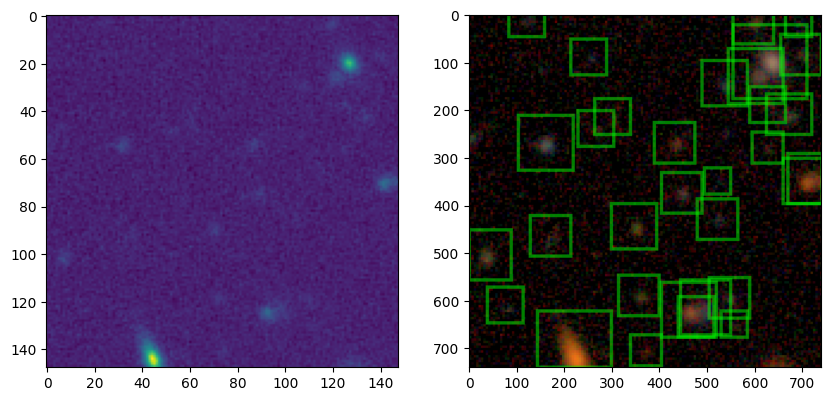

In [14]:
i = img[:, :, 3]
r = img[:, :, 2]
g = img[:, :, 1]
stretch=0.5
Q = 8
lsst_img_rgb = make_lupton_rgb(i, r, g, minimum=0, stretch=stretch, Q=Q)
v0 = Visualizer(
    lsst_img_rgb,
    metadata=astrotest_metadata,
    scale=1 if "comb" in model_type else 5, # use smaller scale for combined model since it has higher-res input
    enable_color_jitter=False,
    instance_mode=ColorMode.SEGMENTATION,  # remove the colors of unsegmented pixels. This option is only available for segmentation models
)
instances_to_draw = sample["instances"]
if instances_to_draw.has("gt_boxes"):
    instances_to_draw.set("pred_boxes", instances_to_draw.gt_boxes)
    instances_to_draw.set("pred_classes", instances_to_draw.gt_classes)

groundTruth = v0.draw_instance_predictions(instances_to_draw, lf=False, alpha=0.5, boxf=True)
plt.figure(figsize=(10, 10))
plt.subplot(1, 2, 1)
# plt.imshow(img[:, :, 3], norm=colors.LogNorm(), cmap='viridis') # show i band
plt.imshow(img[:, :, 3], norm=asinh_norm(img[:, :, 3]), cmap='viridis') # show i band
plt.subplot(1, 2, 2)
plt.imshow(groundTruth.get_image())

Setting colors


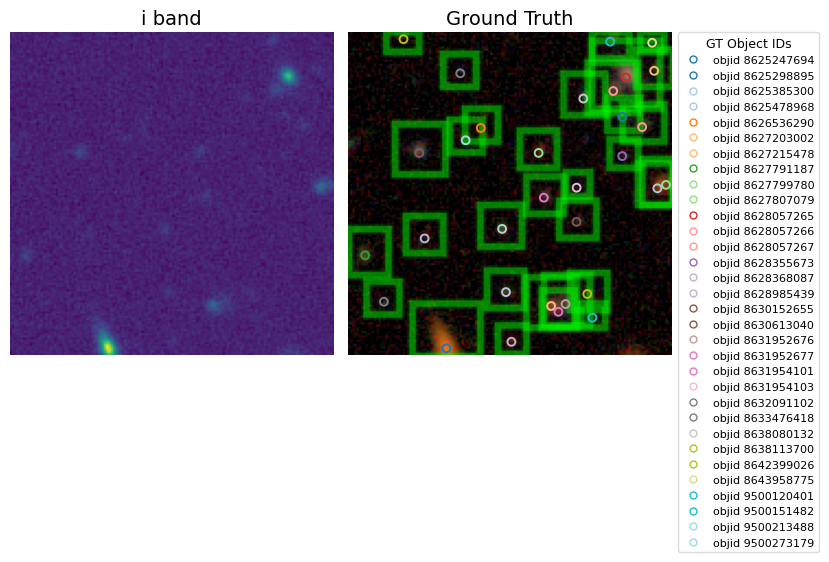

In [15]:
from matplotlib.lines import Line2D

i = img[:, :, 3]
r = img[:, :, 2]
g = img[:, :, 1]
stretch = 0.5
Q = 8
lsst_img_rgb = make_lupton_rgb(i, r, g, minimum=0, stretch=stretch, Q=Q)
v0 = Visualizer(
    lsst_img_rgb,
    metadata=astrotest_metadata,
    scale=1,
    enable_color_jitter=False,
    instance_mode=ColorMode.SEGMENTATION,  # remove the colors of unsegmented pixels. This option is only available for segmentation models
)
instances_to_draw = sample["instances"]
gt_objids = sample["instances"].gt_objid.cpu().numpy()
gt_keypoints = sample["instances"].gt_keypoints.tensor.cpu().numpy()
if instances_to_draw.has("gt_boxes"):
    instances_to_draw.set("pred_boxes", instances_to_draw.gt_boxes)
    instances_to_draw.set("pred_classes", instances_to_draw.gt_classes)

groundTruth = v0.draw_instance_predictions(instances_to_draw, lf=False, alpha=0.5, boxf=True)

fig, (ax_i, ax_gt) = plt.subplots(1, 2, figsize=(10, 10))

# i-band image
ax_i.imshow(img[:, :, 3], norm=asinh_norm(img[:, :, 3]), cmap='viridis')
ax_i.set_title('i band', fontsize=14)
ax_i.axis('off')

# ground-truth overlay
ax_gt.imshow(groundTruth.get_image())
ax_gt.set_title('Ground Truth', fontsize=14)
ax_gt.axis('off')

if gt_objids is not None and gt_keypoints is not None:
    unique_objids = np.unique(gt_objids.astype(int))
    cmap = plt.cm.get_cmap('tab20', max(len(unique_objids), 1))
    objid_to_color = {objid: cmap(i) for i, objid in enumerate(unique_objids)}

    # Plot a small circle at each object location using the same color as its legend entry.
    for objid, kp in zip(gt_objids, gt_keypoints):
        x, y = kp.flatten()[:2]
        color = objid_to_color[int(objid)]
        ax_gt.scatter(
            x,
            y,
            s=32,
            marker='o',
            facecolors='none',
            edgecolors=[color],
            linewidths=1.4,
            zorder=5,
        )

    legend_handles = [
        Line2D(
            [0],
            [0],
            marker='o',
            linestyle='None',
            markersize=5,
            markerfacecolor='none',
            markeredgecolor=objid_to_color[int(objid)],
            label=f'objid {int(objid)}',
        )
        for objid in unique_objids
    ]
    ax_gt.legend(
        handles=legend_handles,
        title='GT Object IDs',
        loc='upper left',
        bbox_to_anchor=(1.02, 1.0),
        borderaxespad=0.0,
        fontsize=8,
        title_fontsize=9,
        framealpha=0.7,
        frameon=True,
    )
else:
    print('sample["instances"] does not have gt_objid/gt_keypoints')

plt.tight_layout(rect=[0, 0, 0.84, 1])

Setting colors


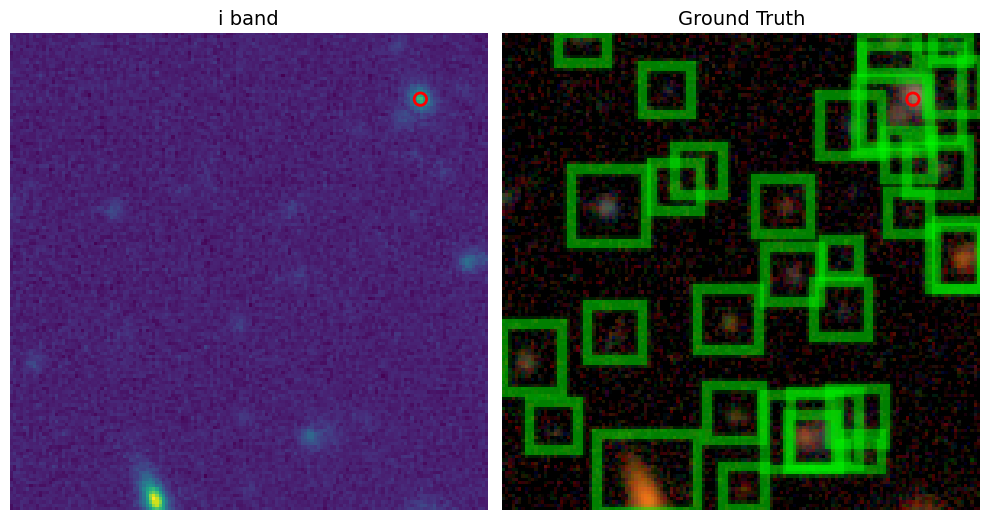

In [16]:
target_objid = 8628057265 # objid i want to select the closest detection to
i = img[:, :, 3]
r = img[:, :, 2]
g = img[:, :, 1]
stretch = 0.5
Q = 8
lsst_img_rgb = make_lupton_rgb(i, r, g, minimum=0, stretch=stretch, Q=Q)
v0 = Visualizer(
    lsst_img_rgb,
    metadata=astrotest_metadata,
    scale=1,
    enable_color_jitter=False,
    instance_mode=ColorMode.SEGMENTATION,
    # remove the colors of unsegmented pixels. This option is only available for segmentation models
)

instances_to_draw = sample["instances"]
gt_objids = sample["instances"].gt_objid.cpu().numpy().astype(np.int64)
gt_keypoints = sample["instances"].gt_keypoints.tensor.cpu().numpy()

if instances_to_draw.has("gt_boxes"):
    instances_to_draw.set("pred_boxes", instances_to_draw.gt_boxes)
    instances_to_draw.set("pred_classes", instances_to_draw.gt_classes)

groundTruth = v0.draw_instance_predictions(instances_to_draw, lf=False, alpha=0.5, boxf=True)

fig, (ax_i, ax_gt) = plt.subplots(1, 2, figsize=(10, 10))

# i-band image
ax_i.imshow(img[:, :, 3], norm=asinh_norm(img[:, :, 3]), cmap='viridis')
ax_i.set_title('i band', fontsize=14)
ax_i.axis('off')

# ground-truth overlay
ax_gt.imshow(groundTruth.get_image())
ax_gt.set_title('Ground Truth', fontsize=14)
ax_gt.axis('off')

# Plot marker(s) for the selected object ID on both panels.
match_idxs = np.where(gt_objids == target_objid)[0]
if len(match_idxs) == 0:
    print(f'objid {target_objid} not found in this sample')
else:
    for idx in match_idxs:
        x, y = gt_keypoints[idx].flatten()[:2]
        ax_i.scatter(
            x, y, s=80, marker='o', facecolors='none', edgecolors='red', linewidths=2.0, zorder=6
        )
        ax_gt.scatter(
            x, y, s=80, marker='o', facecolors='none', edgecolors='red', linewidths=2.0, zorder=6
        )

plt.tight_layout()

Double checking that the filename corresponds to the right cutout

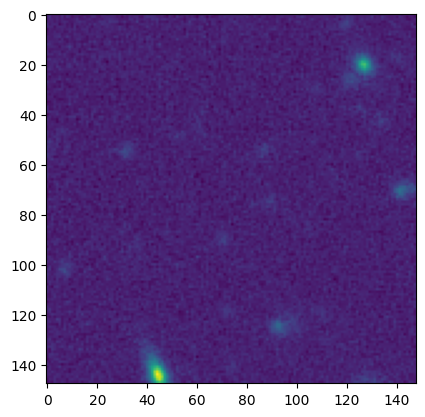

In [10]:
t = np.load(sample['file_name'])[3, :, :]
# change rotation based on image above
# t_rot = t[3, :, :] # no rotation
# rotate 45 degrees clockwise
# t_rot = np.rot90(t[3, :, :]) # rotate 90 degrees to the left
# t_rot = np.rot90(np.rot90(t[3, :, :])) # rotate 180 degrees
# t_rot = np.rot90(np.rot90(np.rot90(t[3, :, :]))) # rotate 90 degrees to the left
# t_rot = np.rot90(np.rot90(np.rot90(np.rot90(t[3, :, :])))) # rotate 90 degrees to the left
plt.imshow(t, norm=asinh_norm(t), cmap='viridis') # show i band
# t.shape

Now, we need to choose a target detection for FeatureAblation, so let's run inference on this image!

In [88]:
batch[0]

{'image': tensor([[[-2.8219e-02, -6.0501e-02, -8.3650e-02,  ..., -2.9012e-02,
           -5.4651e-02, -5.7233e-02],
          [-2.0682e-02, -4.3596e-02, -5.9004e-02,  ..., -2.4683e-02,
           -5.8057e-02, -5.8674e-02],
          [-7.1620e-03, -1.3953e-02, -1.6965e-02,  ..., -4.1146e-04,
           -3.2485e-02, -2.7676e-02],
          ...,
          [ 5.7144e-02,  9.5819e-02,  1.3244e-01,  ...,  2.7908e-02,
            5.2702e-02,  7.3925e-02],
          [ 3.2068e-02,  7.6846e-02,  1.2784e-01,  ...,  4.7368e-02,
            6.5570e-02,  8.0989e-02],
          [ 1.1449e-02,  5.4977e-02,  1.0947e-01,  ...,  5.3778e-02,
            5.6447e-02,  5.9513e-02]],
 
         [[-8.8317e-03, -1.7529e-02, -2.0342e-02,  ..., -1.5670e-02,
           -2.9043e-02, -3.3821e-02],
          [-4.1805e-03, -7.5952e-03, -6.7374e-03,  ..., -1.6834e-02,
           -3.3214e-02, -3.9154e-02],
          [ 2.6346e-03,  6.8230e-03,  1.2525e-02,  ..., -9.1914e-03,
           -2.2947e-02, -2.8099e-02],
          

In [17]:
with torch.no_grad():
    output = model([batch[0]])
instances = output[0]["instances"]

ImageList tensor shape: torch.Size([1, 6, 512, 512])
Image sizes: [(148, 148)]


W0513 14:48:51.690000 711249 site-packages/torch/fx/_symbolic_trace.py:52] is_fx_tracing will return true for both fx.symbolic_trace and torch.export. Please use is_fx_tracing_symbolic_tracing() for specifically fx.symbolic_trace or torch.compiler.is_compiling() for specifically torch.export/compile.


In [108]:
match_idxs = np.where(gt_objids == target_objid)[0]
assert len(match_idxs) == 1, f"Expected exactly one match for objid {target_objid}, but found {len(match_idxs)} matches."
match_idx = match_idxs[0]
x, y = gt_keypoints[match_idx].flatten()[:2]
kpts_x = instances.pred_keypoints[:, :, 0].cpu().numpy()
kpts_y = instances.pred_keypoints[:, :, 1].cpu().numpy()
# Euclidean distance from each predicted keypoint to target GT point
distances = np.sqrt((kpts_x - x)**2 + (kpts_y - y)**2)
# Find the index of the minimum distance
instance_idx, kpt_idx = np.unravel_index(np.argmin(distances), distances.shape)
# Get the closest keypoint coordinates and distance
closest_x = kpts_x[instance_idx, kpt_idx]
closest_y = kpts_y[instance_idx, kpt_idx]
min_distance = distances[instance_idx, kpt_idx]
print(f"Target GT Obj {target_objid}: ({x}, {y})")
print(f"Closest predicted keypoint:")
print(f"  Instance index: {instance_idx}, Keypoint index: {kpt_idx}")
print(f"  Location: ({closest_x}, {closest_y})")
print(f"  Distance: {min_distance} pixels")
target_det_idx = 0  # index of the detection instance we want to analyze (0 for the closest one we just found)

Target GT Obj 8628057265: (442.903564453125, 71.33302307128906)
Closest predicted keypoint:
  Instance index: 6, Keypoint index: 0
  Location: (443.1063232421875, 71.86676788330078)
  Distance: 0.5709594488143921 pixels


In [109]:
for i, (box, score, cls, keypoints) in enumerate(zip(
    instances.pred_boxes.tensor, instances.scores, instances.pred_classes, instances.pred_keypoints
)):
    print(f"det {i}: score={score:.3f}, class={cls.item()}, box={box.tolist()}, keypoints={keypoints.tolist()}")

det 0: score=1.000, class=0, box=[72.82469177246094, 150.3927764892578, 149.7222900390625, 227.0872344970703], keypoints=[[113.27082824707031, 190.73207092285156, 0.6347525715827942]]
det 1: score=1.000, class=0, box=[0.025482177734375, 316.10736083984375, 59.29938507080078, 385.67584228515625], keypoints=[[27.19268798828125, 353.3761901855469, 0.7434716820716858]]
det 2: score=1.000, class=0, box=[211.32107543945312, 278.5045166015625, 274.2562255859375, 341.52740478515625], keypoints=[[244.78659057617188, 311.4930725097656, 0.6266647577285767]]
det 3: score=1.000, class=0, box=[278.50848388671875, 229.04051208496094, 340.970703125, 291.73956298828125], keypoints=[[311.7225341796875, 262.3804931640625, 2.7148854732513428]]
det 4: score=1.000, class=0, box=[340.3537902832031, 69.74205017089844, 406.4096984863281, 135.72718811035156], keypoints=[[375.35357666015625, 105.23405456542969, 0.45443207025527954]]
det 5: score=1.000, class=0, box=[280.6317443847656, 392.1448669433594, 360.7729

Setting colors
detected instances: 30

Detection IDs:
  id=00 | score=1.000 | class=0
  id=01 | score=0.999 | class=0
  id=02 | score=0.999 | class=0
  id=03 | score=0.998 | class=0
  id=04 | score=0.996 | class=0
  id=05 | score=0.992 | class=0
  id=06 | score=0.991 | class=0
  id=07 | score=0.987 | class=0
  id=08 | score=0.985 | class=0
  id=09 | score=0.983 | class=0
  id=10 | score=0.978 | class=0
  id=11 | score=0.973 | class=0
  id=12 | score=0.965 | class=0
  id=13 | score=0.962 | class=0
  id=14 | score=0.960 | class=0
  id=15 | score=0.948 | class=0
  id=16 | score=0.922 | class=0
  id=17 | score=0.900 | class=0
  id=18 | score=0.888 | class=0
  id=19 | score=0.887 | class=0
  id=20 | score=0.883 | class=0
  id=21 | score=0.880 | class=0
  id=22 | score=0.878 | class=0
  id=23 | score=0.796 | class=0
  id=24 | score=0.750 | class=0
  id=25 | score=0.653 | class=0
  id=26 | score=0.648 | class=0
  id=27 | score=0.603 | class=0
  id=28 | score=0.530 | class=0
  id=29 | score=0.

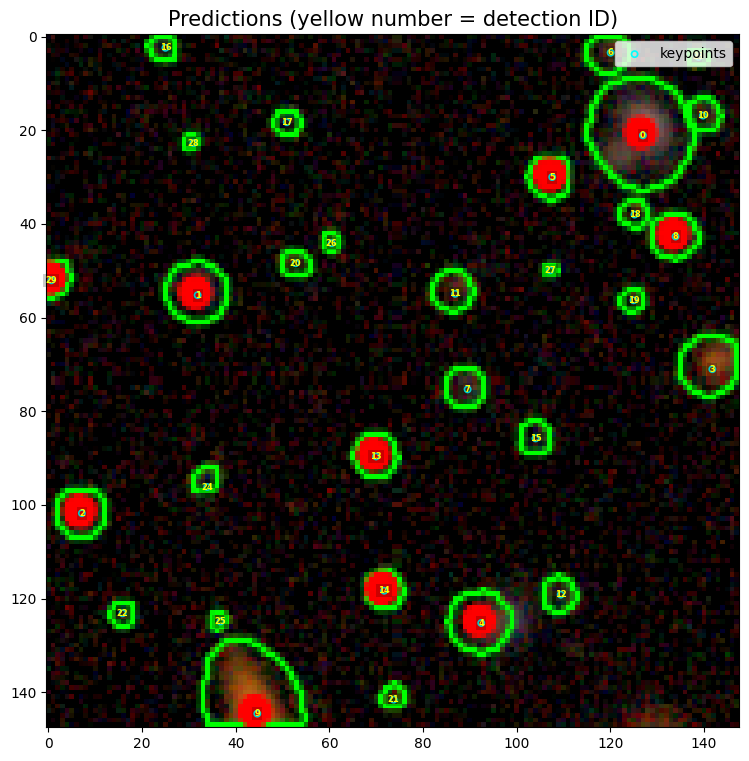

In [60]:
v0 = Visualizer(
    lsst_img_rgb,
    metadata=astrotest_metadata,
    scale=1,
    instance_mode=ColorMode.SEGMENTATION,
    enable_color_jitter=False  # remove colors of unsegmented pixels
)
out = v0.draw_instance_predictions(instances, alpha=0, lf=False)

print("detected instances:", len(instances))
print("\nDetection IDs:")
for det_id, (score, cls) in enumerate(zip(instances.scores, instances.pred_classes)):
    print(f"  id={det_id:02d} | score={float(score):.3f} | class={int(cls)}")

fig, ax1 = plt.subplots(1, 1, figsize=(9, 9))
ax1.imshow(out.get_image())

# Draw all keypoints
kpts_x = instances.pred_keypoints[:, :, 0].cpu().numpy()
kpts_y = instances.pred_keypoints[:, :, 1].cpu().numpy()
# Label each detection with its ID near the mean keypoint location
for det_id in range(len(instances)):
    x_text = float(kpts_x[det_id].mean())
    y_text = float(kpts_y[det_id].mean())
    ax1.text(
        x_text,
        y_text,
        str(det_id),
        color='yellow',
        fontsize=6,
        fontweight='bold',
        ha='center',
        va='center',
        bbox=dict(facecolor='black', alpha=0.2, edgecolor='none', pad=1.5),
    )
ax1.scatter(
    kpts_x,
    kpts_y,
    s=20,
    facecolors='none',
    edgecolors='cyan',
    linewidths=1.2,
    label='keypoints',
)

ax1.set_title('Predictions (yellow number = detection ID)', fontsize=15)
ax1.legend(loc='upper right')

Setting colors
detected instances: 33

Detection IDs:
  id=00 | score=1.000 | class=0
  id=01 | score=1.000 | class=0
  id=02 | score=1.000 | class=0
  id=03 | score=1.000 | class=0
  id=04 | score=1.000 | class=0
  id=05 | score=1.000 | class=0
  id=06 | score=1.000 | class=0
  id=07 | score=1.000 | class=0
  id=08 | score=1.000 | class=0
  id=09 | score=1.000 | class=0
  id=10 | score=0.999 | class=0
  id=11 | score=0.999 | class=0
  id=12 | score=0.998 | class=0
  id=13 | score=0.998 | class=0
  id=14 | score=0.996 | class=0
  id=15 | score=0.992 | class=0
  id=16 | score=0.991 | class=0
  id=17 | score=0.990 | class=0
  id=18 | score=0.990 | class=0
  id=19 | score=0.990 | class=0
  id=20 | score=0.989 | class=0
  id=21 | score=0.987 | class=0
  id=22 | score=0.987 | class=0
  id=23 | score=0.978 | class=0
  id=24 | score=0.964 | class=0
  id=25 | score=0.951 | class=0
  id=26 | score=0.804 | class=0
  id=27 | score=0.766 | class=0
  id=28 | score=0.751 | class=0
  id=29 | score=0.

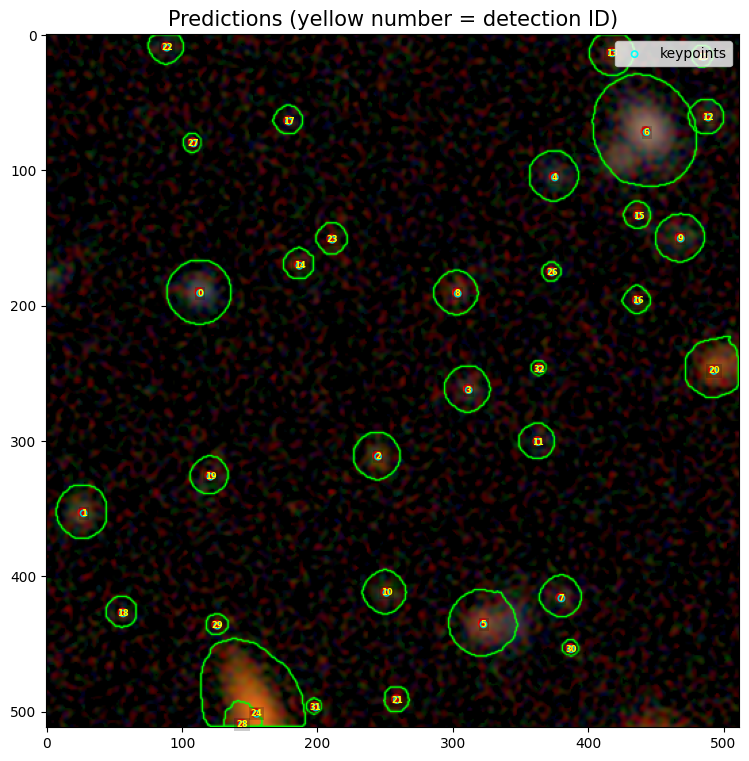

In [110]:
v0 = Visualizer(
    lsst_img_rgb,
    metadata=astrotest_metadata,
    scale=1,
    instance_mode=ColorMode.SEGMENTATION,
    enable_color_jitter=False  # remove colors of unsegmented pixels
)
out = v0.draw_instance_predictions(instances, alpha=0, lf=False)

print("detected instances:", len(instances))
print("\nDetection IDs:")
for det_id, (score, cls) in enumerate(zip(instances.scores, instances.pred_classes)):
    print(f"  id={det_id:02d} | score={float(score):.3f} | class={int(cls)}")

fig, ax1 = plt.subplots(1, 1, figsize=(9, 9))
ax1.imshow(out.get_image())

# Draw all keypoints
kpts_x = instances.pred_keypoints[:, :, 0].cpu().numpy()
kpts_y = instances.pred_keypoints[:, :, 1].cpu().numpy()
# Label each detection with its ID near the mean keypoint location
for det_id in range(len(instances)):
    x_text = float(kpts_x[det_id].mean())
    y_text = float(kpts_y[det_id].mean())
    ax1.text(
        x_text,
        y_text,
        str(det_id),
        color='yellow',
        fontsize=6,
        fontweight='bold',
        ha='center',
        va='center',
        bbox=dict(facecolor='black', alpha=0.2, edgecolor='none', pad=1.5),
    )
ax1.scatter(
    kpts_x,
    kpts_y,
    s=20,
    facecolors='none',
    edgecolors='cyan',
    linewidths=1.2,
    label='keypoints',
)

ax1.set_title('Predictions (yellow number = detection ID)', fontsize=15)
ax1.legend(loc='upper right')

Ok, let's do det0 (it's the closest to the gt obj we want to analyze!)

In [111]:
input_tensor.shape

torch.Size([1, 9, 512, 512])

In [112]:
# store the GT keypoint location from our selection code
class CaptumWrapper(torch.nn.Module):
    """
    so FeatureAblation can call forward(tensor) -> scores.
    Holds a reference to the preprocessed batch so we only vary the image tensor
    """
    def __init__(self, model, batched_inputs, target_kp_xy):
        super().__init__()
        self.model = model
        self.target_kp_xy = target_kp_xy  # (x, y) GT keypoint
        # store everything except the image itself
        self.meta = [{k: v for k, v in b.items() if k != "image"} for b in batched_inputs]

    def forward(self, image_tensor):
        # image_tensor: (1, C, H, W) float, already on device
        batched = [{**self.meta[0], "image": image_tensor[0]}]
        with torch.no_grad():
            output = self.model(batched)
        instances = output[0]["instances"]
        if len(instances) == 0:
            return image_tensor.sum() * 0

        kpts_x = instances.pred_keypoints[:, :, 0].cpu().numpy()
        kpts_y = instances.pred_keypoints[:, :, 1].cpu().numpy()
        x, y = self.target_kp_xy
        distances = np.sqrt((kpts_x - x)**2 + (kpts_y - y)**2)
        instance_idx, _ = np.unravel_index(np.argmin(distances), distances.shape)
        score = instances.scores[instance_idx]
        return score.unsqueeze(0)

In [ ]:
img_idx = 0 # which img from the batch to analyze
img_tensor = batch[0]["image"].unsqueeze(0).float() # (1, 6, H, W)
H, W = img_tensor.shape[2:]  # cutout size 
# For combined: Two groups: Rubin (0–5) = group 0, Roman (6–8) = group 1
# Since we're ablating Rubin-only inference, we just do Rubin bands
feature_mask = torch.zeros((1, 6, H, W), dtype=torch.long)
# all 6 bands as one group (modality-level ablation)
# feature_mask[:, :, :, :] = 0  # everything is group 0 = already trivial

# per-band ablation (for Rubin analysis)
for band_idx in range(6):
    feature_mask[0, band_idx, :, :] = band_idx  # each band is its own group

rubin_pixel_mean = model.pixel_mean  # (6, 1, 1) tensor on device
# rubin_pixel_mean = model.rubin_pixel_mean  # (6, 1, 1) tensor on device
baseline = rubin_pixel_mean.view(1, 6, 1, 1).expand(1, 6, H, W).clone()
# spatial + band groups (coarse spatial regions × bands)
# e.g., 4 quadrants × 6 bands = 24 features
target_kp_xy = (closest_x, closest_y)
wrapped = CaptumWrapper(model, [batch[0]], target_kp_xy=target_kp_xy)
ablator = FeatureAblation(wrapped)
attributions = ablator.attribute(
    img_tensor,                    # (1, 6, H, W)
    baselines=baseline,
    feature_mask=feature_mask,      # (1, 6, H, W), dtype=torch.long
)

In [ ]:
img_idx = 0 # which img from the batch to analyze
img_tensor = batch[0]["image"].unsqueeze(0).float() # (1, 6, H, W)
H, W = img_tensor.shape[2:]  # cutout size 
# For combined: Two groups: Rubin (0–5) = group 0, Roman (6–8) = group 1
feature_mask = torch.zeros((1, 9, H, W), dtype=torch.long)
feature_mask[0, :6, :, :] = 0  # Rubin = group 0
feature_mask[0, 6:, :, :] = 1  # Roman = group 1
# all 6 bands as one group (modality-level ablation)
# feature_mask[:, :, :, :] = 0  # everything is group 0 = already trivial

rubin_pixel_mean = model.pixel_mean  # (9, 1, 1) tensor on device
baseline = rubin_pixel_mean.view(1, 9, 1, 1).expand(1, 9, H, W).clone()
target_kp_xy = (closest_x, closest_y)
wrapped = CaptumWrapper(model, [batch[0]], target_kp_xy=target_kp_xy)
ablator = FeatureAblation(wrapped) # attribution = f(original input) - f(input with that group replaced by baseline)
attr_modality = ablator.attribute(
    img_tensor,                    # (1, 9, H, W)
    baselines=baseline,
    feature_mask=feature_mask,      # (1, 9, H, W), dtype=torch.long
)

feature_mask_bands = torch.zeros((1, 9, H, W), dtype=torch.long)
for band_idx in range(9):
    feature_mask_bands[0, band_idx, :, :] = band_idx
attr_bands = ablator.attribute(img_tensor, baselines=baseline, feature_mask=feature_mask_bands)

In [64]:
attributions.shape

torch.Size([1, 6, 148, 148])

In [74]:
# One importance value per band
band_names = ['u', 'g', 'r', 'i', 'z', 'y']
band_importance = attributions[0, :, 0, 0].cpu()
for name, val in zip(band_names, band_importance):
    print(f"{name}: {val:.4f}")
print()
print("Fractional importance relative to baseline score:")
baseline_score = float(instances.scores[instance_idx])
frac_drops = [v / baseline_score for v in band_importance]
for name, f in zip(band_names, frac_drops):
    print(f"{name}: {f*100:.2f}% score drop")

u: 0.0004
g: 0.0008
r: 0.0014
i: 0.0003
z: 0.0001
y: 0.0001

Fractional importance relative to baseline score:
u: 0.04% score drop
g: 0.08% score drop
r: 0.14% score drop
i: 0.03% score drop
z: 0.01% score drop
y: 0.01% score drop


In [121]:
band_names_9 = ['u', 'g', 'r', 'i', 'z', 'y', 'Y106', 'J129', 'H158']
band_importance_9 = attr_bands[0, :, 0, 0].cpu()
for name, val in zip(band_names_9, band_importance_9):
    print(f"{name}: {val:.4f}")
print()
print("Fractional importance relative to baseline score:")
baseline_score = float(instances.scores[instance_idx])
frac_drops = [v / baseline_score for v in band_importance_9]
for name, f in zip(band_names_9, frac_drops):
    print(f"{name}: {f*100:.3f}% score drop")

u: 0.0006
g: -0.0000
r: 0.0000
i: 0.0001
z: 0.0000
y: -0.0001
Y106: 0.0203
J129: 0.0014
H158: 0.0307

Fractional importance relative to baseline score:
u: 0.064% score drop
g: -0.001% score drop
r: 0.005% score drop
i: 0.008% score drop
z: 0.002% score drop
y: -0.009% score drop
Y106: 2.034% score drop
J129: 0.136% score drop
H158: 3.067% score drop


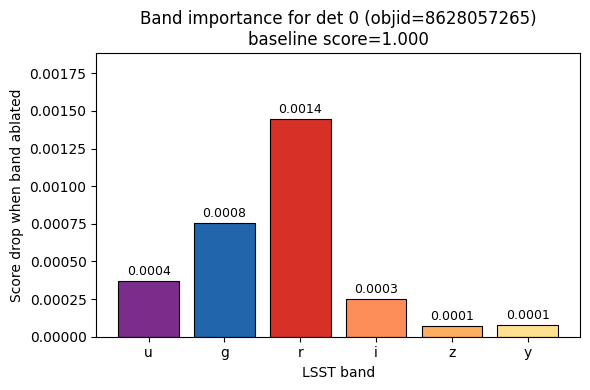

In [69]:
fig, ax = plt.subplots(figsize=(6, 4))
colors = ['#7b2d8b', '#2166ac', '#d73027', '#fc8d59', '#fdae61', '#fee090']
bars = ax.bar(band_names, band_importance, color=colors, edgecolor='black', linewidth=0.8)

# annotate score drop on each bar
for bar, val in zip(bars, band_importance):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.00002,
            f'{val:.4f}', ha='center', va='bottom', fontsize=9)

ax.set_ylabel('Score drop when band ablated')
ax.set_xlabel('LSST band')
ax.set_title(f'Band importance for det {target_det_idx} (objid={target_objid})\nbaseline score={instances.scores[instance_idx]:.3f}')
ax.set_ylim(0, max(band_importance) * 1.3)
plt.tight_layout()

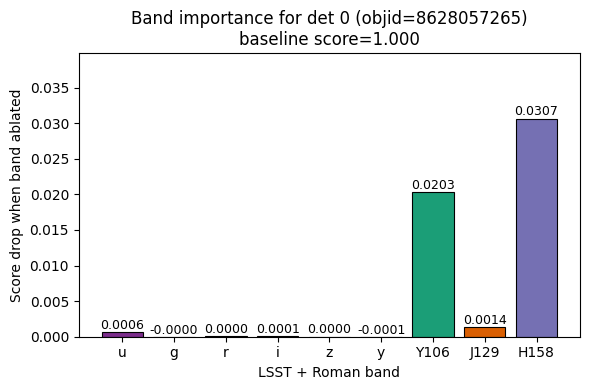

In [123]:
fig, ax = plt.subplots(figsize=(6, 4))
colors = ['#7b2d8b', '#2166ac', '#d73027', '#fc8d59', '#fdae61', '#fee090', '#1b9e77', '#d95f02', '#7570b3']
bars = ax.bar(band_names_9, band_importance_9, color=colors, edgecolor='black', linewidth=0.8)

# annotate score drop on each bar
for bar, val in zip(bars, band_importance_9):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.00002,
            f'{val:.4f}', ha='center', va='bottom', fontsize=9)

ax.set_ylabel('Score drop when band ablated')
ax.set_xlabel('LSST + Roman band')
ax.set_title(f'Band importance for det {target_det_idx} (objid={target_objid})\nbaseline score={instances.scores[instance_idx]:.3f}')
ax.set_ylim(0, max(band_importance_9) * 1.3)
plt.tight_layout()

In [ ]:
# One importance value per band
band_names = ['u', 'g', 'r', 'i', 'z', 'y', ]
band_importance = attributions[0, :, 0, 0].cpu()
for name, val in zip(band_names, band_importance):
    print(f"{name}: {val:.4f}")
print()
print("Fractional importance relative to baseline score:")
baseline_score = float(instances.scores[instance_idx])
frac_drops = [v / baseline_score for v in band_importance]
for name, f in zip(band_names, frac_drops):
    print(f"{name}: {f*100:.2f}% score drop")

In [114]:
attributions.shape

torch.Size([1, 9, 512, 512])

In [116]:
# modality-level result
rubin_importance = attributions[0, 0, 0, 0].item()   # group 0 value
roman_importance = attributions[0, 6, 0, 0].item()   # group 1 value
survey_importance = [rubin_importance, roman_importance]
print(f"Rubin: {rubin_importance:.4f}")
print(f"Roman: {roman_importance:.4f}")

Rubin: 0.0055
Roman: 0.2062


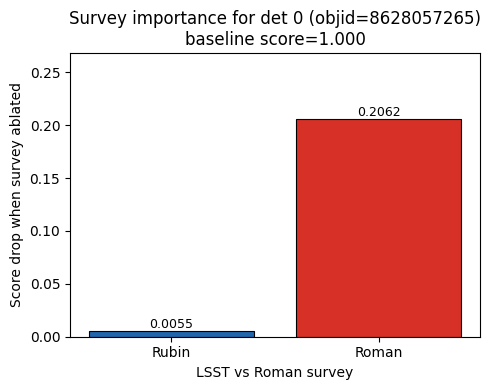

In [118]:
fig, ax = plt.subplots(figsize=(5, 4))
colors = ['#2166ac', '#d73027']
bars = ax.bar(['Rubin', 'Roman'], survey_importance, color=colors, edgecolor='black', linewidth=0.8)

# annotate score drop on each bar
for bar, val in zip(bars, survey_importance):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.00002,
            f'{val:.4f}', ha='center', va='bottom', fontsize=9)

ax.set_ylabel('Score drop when survey ablated')
ax.set_xlabel('LSST vs Roman survey')
ax.set_title(f'Survey importance for det {target_det_idx} (objid={target_objid})\nbaseline score={instances.scores[instance_idx]:.3f}')
ax.set_ylim(0, max(survey_importance) * 1.3)
plt.tight_layout()

In [ ]:
# class BaselineGradCAMWrapper(torch.nn.Module):
#     """
#     so GradCAM can call forward(tensor) -> scores.
#     Holds a reference to the preprocessed batch so we only vary the image tensor
#     """
#     def __init__(self, model, batched_inputs):
#         super().__init__()
#         self.model = model
#         # store everything except the image itself
#         self.meta = [{k: v for k, v in b.items() if k != "image"} for b in batched_inputs]

#     def forward(self, image_tensor):
#         # image_tensor: (1, C, H, W) float, already on device
#         batched = [{**self.meta[0], "image": image_tensor[0]}]
#         output  = self.model(batched)
#         instances = output[0]["instances"]
#         if len(instances) == 0:
#             return image_tensor.sum() * 0  # differentiable zero
#         return instances.scores  # (N,) — GradCAM sums this

# class TopScoreTarget:
#     """Maximise the score of the highest-confidence detection."""
#     def __call__(self, output):
#         return output.max()

img_idx = 1   # which image in the batch to analyse
# ── Target layer options ──────────────────────────────────────────────────
# Swin stage 3 (deepest, highest-level features):
#   model.backbone.bottom_up.layers[-1].blocks[-1].norm2
# FPN output for a specific scale (p2–p6):
#   model.backbone.fpn_output3
# ─────────────────────────────────────────────────────────────────────────
def swin_reshape_transform(tensor):
    # tensor: (B, H*W, C) -> (B, C, H, W)
    B, L, C = tensor.shape
    H = W = int(L ** 0.5)
    result = tensor.reshape(B, H, W, C)
    result = result.permute(0, 3, 1, 2)  # (B, C, H, W)
    return result

target_layer = model.backbone.bottom_up.layers[-1].blocks[-1].norm2
# backbone.layers[-1].blocks[0].norm1
wrapped = BaselineGradCAMWrapper(model, [batch[img_idx]])
wrapped.eval()

image_tensor = batch[img_idx]["image"].unsqueeze(0).float()
cam = GradCAM(model=wrapped, target_layers=[target_layer],
              reshape_transform=swin_reshape_transform)
grayscale_cam = cam(image_tensor, targets=[TopScoreTarget()])
# grayscale_cam: (1, H, W)

print(f"CAM map shape: {grayscale_cam.shape}, range [{grayscale_cam.min():.3f}, {grayscale_cam.max():.3f}]")

: 

Setting colors


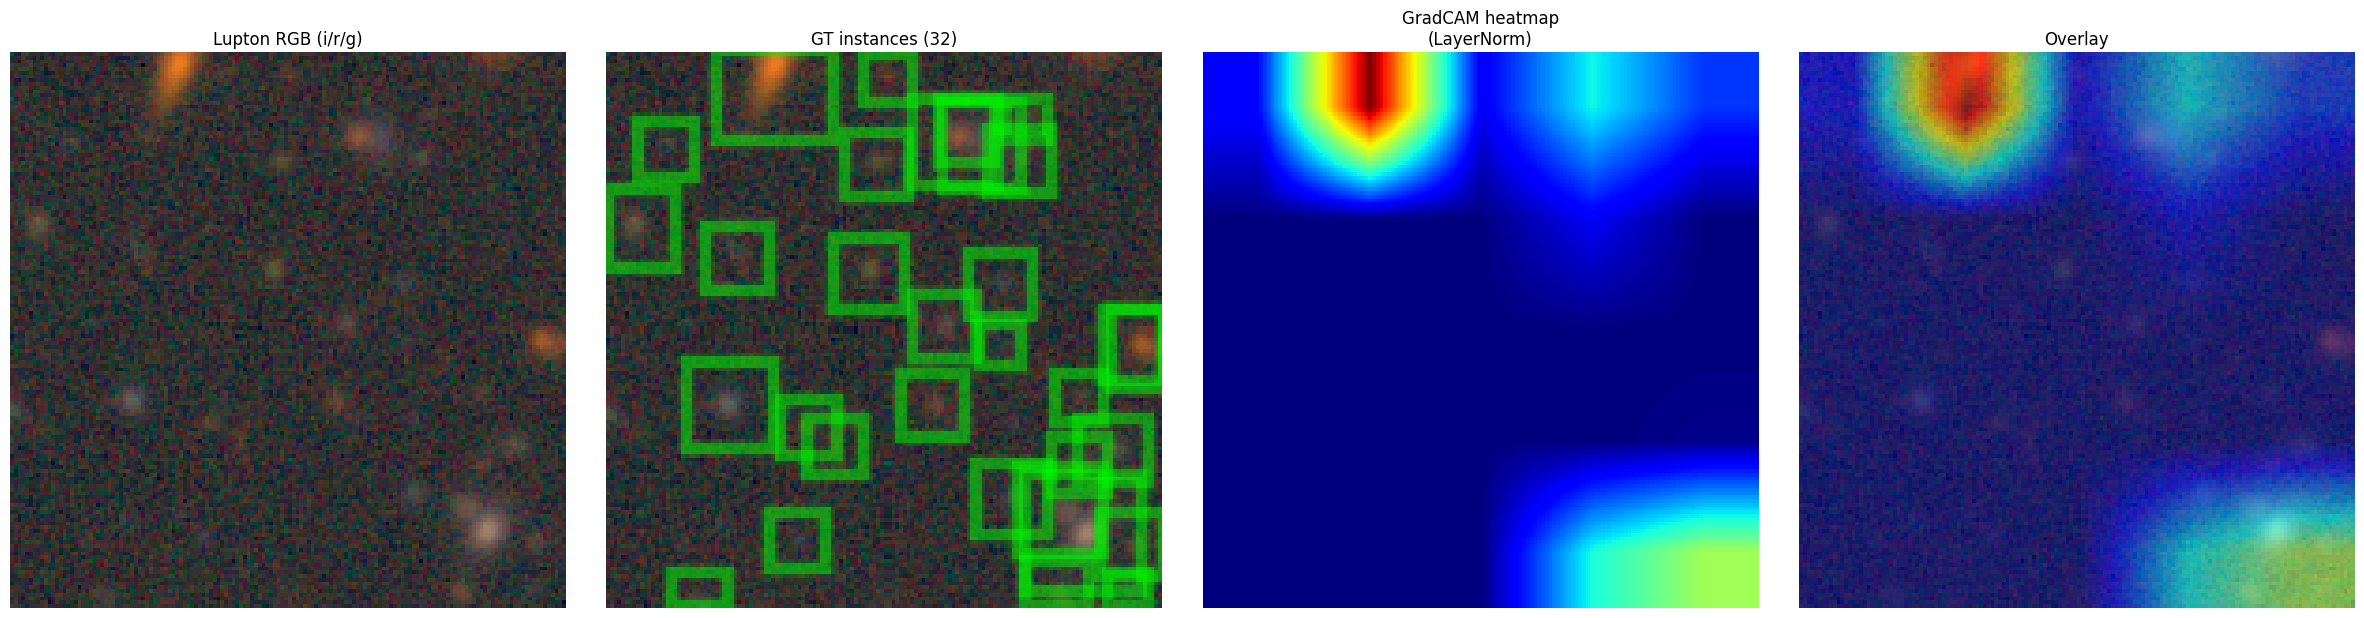

In [ ]:
def make_rgb(raw, pmin_pct=1, pmax_pct=99.5):
    i, r, g = raw[3].astype(float), raw[2].astype(float), raw[1].astype(float)
    pmin   = np.percentile([i, r, g], pmin_pct)
    pmax   = np.percentile([i, r, g], pmax_pct)
    return make_lupton_rgb(i, r, g, minimum=pmin, stretch=pmax - pmin, Q=8)

raw_img = batch[img_idx]["image"].cpu().numpy()
rgb     = make_rgb(raw_img)
rgb_f   = rgb.astype(np.float32) / 255.0

cam_overlay = show_cam_on_image(rgb_f, grayscale_cam[0], use_rgb=True)

# --- draw GT instances on a copy of the RGB ---
gt_inst = batch[img_idx]["instances"]
v = Visualizer(rgb.copy(), metadata=astrotest_metadata,
               scale=1.0, instance_mode=ColorMode.SEGMENTATION,
               enable_color_jitter=False)
out = v.draw_instance_predictions(
    Instances(rgb.shape[:2], pred_boxes=gt_inst.gt_boxes,
              pred_classes=gt_inst.gt_classes),
    alpha=0.5, lf=False, boxf=True, draw_masks=False
)
rgb_with_instances = out.get_image()

fig, axes = plt.subplots(1, 4, figsize=(24, 6))

axes[0].imshow(rgb, origin="lower")
axes[0].set_title("Lupton RGB (i/r/g)")
axes[0].axis("off")

axes[1].imshow(rgb_with_instances, origin="lower")
axes[1].set_title(f"GT instances ({len(gt_inst)})")
axes[1].axis("off")

axes[2].imshow(grayscale_cam[0], cmap="jet", origin="lower", vmin=0, vmax=1)
axes[2].set_title(f"GradCAM heatmap\n({target_layer.__class__.__name__})")
axes[2].axis("off")

axes[3].imshow(cam_overlay, origin="lower")
axes[3].set_title("Overlay")
axes[3].axis("off")

plt.tight_layout()

In [ ]:
class RPNObjectnessTarget:
    """Sum objectness logits across all anchors — works in training mode where
    all proposals are unfiltered."""
    def __call__(self, output):
        # output is a list of (B, num_anchors, H, W) tensors, one per FPN level
        # sum across all levels so gradient flows from every scale
        return sum(o.sum() for o in output)

class RPNHeadWrapper(torch.nn.Module):
    """Runs just the RPN head (not full model) so GradCAM gets a clean output."""
    def __init__(self, model, batched_inputs):
        super().__init__()
        self.model = model
        self.batched_inputs = batched_inputs

    def forward(self, image_tensor):
        batched = [{**self.batched_inputs[0], "image": image_tensor[0]}]
        with torch.enable_grad():
            images = self.model.preprocess_image(batched)
            features = self.model.backbone(images.tensor)
            # return objectness logits for all FPN levels
            fpn_features = [features[k] for k in self.model.proposal_generator.in_features]
            logits, _ = self.model.proposal_generator.rpn_head(fpn_features)
        return logits  # list of (1, num_anchors, H, W)

rpn_wrapped = RPNHeadWrapper(model, [batch[img_idx]])
rpn_wrapped.train()

target_layer = model.proposal_generator.rpn_head.objectness_logits

image_tensor = batch[img_idx]["image"].unsqueeze(0).float()
cam = GradCAM(model=rpn_wrapped, target_layers=[target_layer])
grayscale_cam = cam(image_tensor, targets=[RPNObjectnessTarget()])
print(f"CAM map shape: {grayscale_cam.shape}, range [{grayscale_cam.min():.3f}, {grayscale_cam.max():.3f}]")

CAM map shape: (1, 148, 148), range [0.000, 1.000]


Setting colors


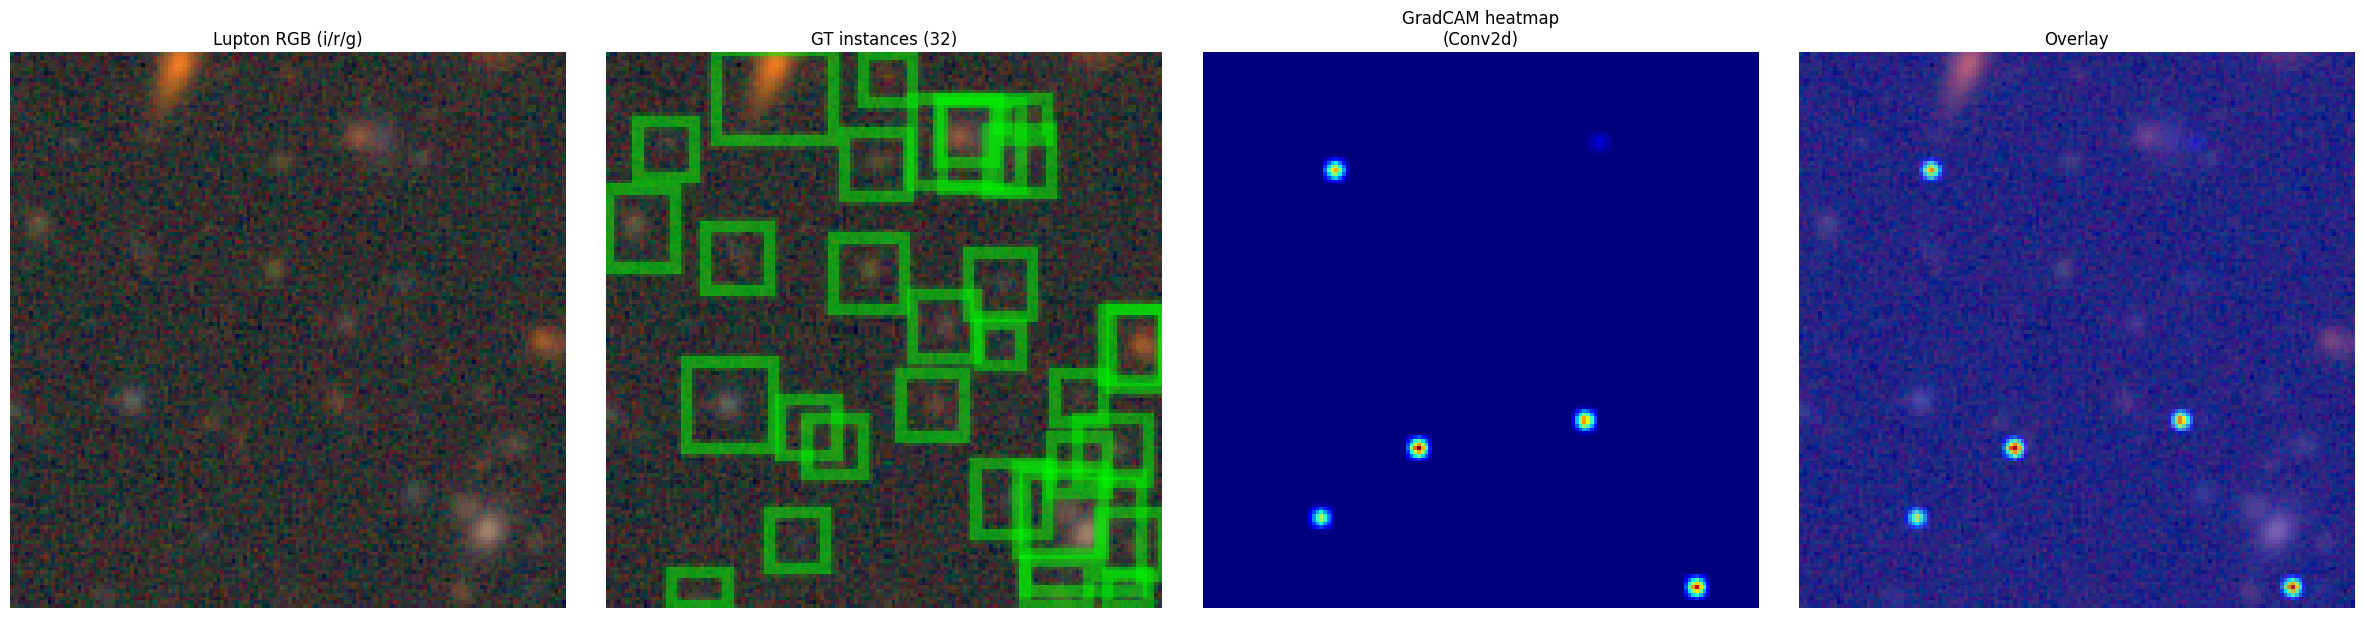

In [ ]:
def make_rgb(raw, pmin_pct=1, pmax_pct=99.5):
    i, r, g = raw[3].astype(float), raw[2].astype(float), raw[1].astype(float)
    pmin   = np.percentile([i, r, g], pmin_pct)
    pmax   = np.percentile([i, r, g], pmax_pct)
    return make_lupton_rgb(i, r, g, minimum=pmin, stretch=pmax - pmin, Q=8)

raw_img = batch[img_idx]["image"].cpu().numpy()
rgb     = make_rgb(raw_img)
rgb_f   = rgb.astype(np.float32) / 255.0

cam_overlay = show_cam_on_image(rgb_f, grayscale_cam[0], use_rgb=True)

# --- draw GT instances on a copy of the RGB ---
gt_inst = batch[img_idx]["instances"]
v = Visualizer(rgb.copy(), metadata=astrotest_metadata,
               scale=1.0, instance_mode=ColorMode.SEGMENTATION,
               enable_color_jitter=False)
out = v.draw_instance_predictions(
    Instances(rgb.shape[:2], pred_boxes=gt_inst.gt_boxes,
              pred_classes=gt_inst.gt_classes),
    alpha=0.5, lf=False, boxf=True, draw_masks=False
)
rgb_with_instances = out.get_image()

fig, axes = plt.subplots(1, 4, figsize=(24, 6))

axes[0].imshow(rgb, origin="lower")
axes[0].set_title("Lupton RGB (i/r/g)")
axes[0].axis("off")

axes[1].imshow(rgb_with_instances, origin="lower")
axes[1].set_title(f"GT instances ({len(gt_inst)})")
axes[1].axis("off")

axes[2].imshow(grayscale_cam[0], cmap="jet", origin="lower", vmin=0, vmax=1)
axes[2].set_title(f"GradCAM heatmap\n({target_layer.__class__.__name__})")
axes[2].axis("off")

axes[3].imshow(cam_overlay, origin="lower")
axes[3].set_title("Overlay")
axes[3].axis("off")

plt.tight_layout()

In [ ]:
print(model.proposal_generator.rpn_head)

StandardRPNHead(
  (conv): Sequential(
    (conv0): Conv2d(
      256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)
      (activation): ReLU()
    )
    (conv1): Conv2d(
      256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)
      (activation): ReLU()
    )
  )
  (objectness_logits): Conv2d(256, 3, kernel_size=(1, 1), stride=(1, 1))
  (anchor_deltas): Conv2d(256, 12, kernel_size=(1, 1), stride=(1, 1))
)


# Visualizing Attention

## Grabbing Target Layer and Block

In [ ]:
# specific layer and block I want to analyze
layer_idx = 2  # Layer 3 (0-indexed)
block_idx = 11  # Block 11
target_block = backbone.layers[layer_idx].blocks[block_idx]

Here is a brief snippet of what this target block looks like:
```
  (11): SwinTransformerBlock(
    (norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
    (attn): WindowAttention(
      (qkv): Linear(in_features=512, out_features=1536, bias=True)
      (attn_drop): Dropout(p=0.0, inplace=False)
      (proj): Linear(in_features=512, out_features=512, bias=True)
      (proj_drop): Dropout(p=0.0, inplace=False)
      (softmax): Softmax(dim=-1)
    )
    (drop_path): DropPath(drop_prob=0.261)
    (norm2): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
    (mlp): Mlp(
      (fc1): Linear(in_features=512, out_features=2048, bias=True)
      (act): GELU(approximate='none')
      (fc2): Linear(in_features=2048, out_features=512, bias=True)
      (drop): Dropout(p=0.0, inplace=False)
    )
  )
  ```

Now, let's check out the feature maps at the layer and block we're interested in and see how it changes as the image is input to the model.

In [ ]:
# Let's add a hook to capture the actual feature map dimensions at our layer
feature_map_info = {}
def capture_feature_map(name):
    def hook(module, input, output):
        if isinstance(input, tuple):
            inp = input[0]
        else:
            inp = input
        feature_map_info[name] = {
            'input_shape': inp.shape if isinstance(inp, torch.Tensor) else None,
            'output_shape': output.shape if isinstance(output, torch.Tensor) else None,
            'tokens': inp.flatten(0, 1) # combines batch and token dimensions so we have (batch*num_tokens, channels)
        }
    return hook

print("Setting up hooks...")
# hook on the target block to see its input/output
hook = target_block.register_forward_hook(capture_feature_map('target_block'))
# forward pass with a single sample
print("\n Running forward pass...")
model.eval()
with torch.no_grad():
    # forward pass through just the backbone
    _ = backbone(input_tensor)
hook.remove()

Setting up hooks...

 Running forward pass...


In [ ]:
print(f"\nAt Layer {layer_idx}, Block {block_idx}:")
if feature_map_info['target_block']['input_shape'] is not None:
    inp_shape = feature_map_info['target_block']['input_shape']
    print(f"   Input shape: {inp_shape}")
    if len(inp_shape) == 4:  # [B, H*W (num_of_tokens), C] or similar
        print(f"   -> Likely (B, num_tokens, channels)")
if feature_map_info['target_block']['output_shape'] is not None:
    out_shape = feature_map_info['target_block']['output_shape']
    print(f"   Output shape: {out_shape}")


At Layer 2, Block 11:
   Input shape: torch.Size([1, 100, 512])
   Output shape: torch.Size([1, 100, 512])


In [ ]:
feature_map_info['target_block']['tokens'].shape

torch.Size([100, 512])

So, we have at Layer 2, Block 11, a feature map that's a tensor of size [1, 100, 512]. Here, the batch size is one and the 100 patches correspond to the spatially downsampled patches of the original image. Each patch carries a 512-dimensional feature vector (what we expect since this block's `in_features=512`). This representation means that, although spatial resolution is reduced, each patch embeds a rich, high-level representation of its corresponding image region, capturing both local details and contextual relationships as computed by the block.

Additionally, we expect the input and output shapes to be the same for this block at this layer/stage since the block follows a residual architecture. We start with a `LayerNorm` + `WindowedAttention` + `Residual Connection w/ the DropPath` and then move onto the second part of the block: `LayerNorm` + `MLP` + `Residual Connection w/ DropPath` (512 --> 2048 --> 512).

Now, let's calculate the actual feature map size using the fact that we know how many patches we have.

In [ ]:
# actual feature map size from the number of tokens
num_patches = feature_map_info['target_block']['tokens'].shape[0]
# factors to determine H×W
print(f"Number of tokens at Layer {layer_idx}, Block {block_idx}: {num_patches}")
print(f"Possible spatial dimensions (H×W = {num_patches}):")
for h in range(1, int(math.sqrt(num_patches)) + 1):
    if num_patches % h == 0:
        w = num_patches // h
        print(f"  {h}×{w}")

Number of tokens at Layer 2, Block 11: 100
Possible spatial dimensions (H×W = 100):
  1×100
  2×50
  4×25
  5×20
  10×10


The feature map will have the dimensions that are the closest to a square.

In [ ]:
feature_h, feature_w = 10, 10
print(f"\nActual feature map size: {feature_h}x{feature_w}")
# Now let's find out how many windows we expect to see
# the config set window_size=7 (which is the default)
window_size = 7
padded_h = math.ceil(feature_h / window_size) * window_size
padded_w = math.ceil(feature_w / window_size) * window_size
num_windows_h = padded_h // window_size
num_windows_w = padded_w // window_size
expected_windows = num_windows_h * num_windows_w

print(f"Window partitioning:")
print(f"  Original feature map: {feature_h}x{feature_w}")
print(f"  Padded to: {padded_h}x{padded_w}")
print(f"  Number of windows: {num_windows_h}x{num_windows_w} = {expected_windows}")


Actual feature map size: 10x10
Window partitioning:
  Original feature map: 10x10
  Padded to: 14x14
  Number of windows: 2x2 = 4


So, we should expect to see the first dimension of the attention tensors to be 4 as it's defined as `batch_size * num_windows = 1 * 4 = 4`. By Layer 2, Block 11, the image features have been heavily downsampled. The resulting feature map contains 100 tokens that must be partitioned into windows for the local attention mechanism.

Downsample factor (padded_size // feature_h): 16


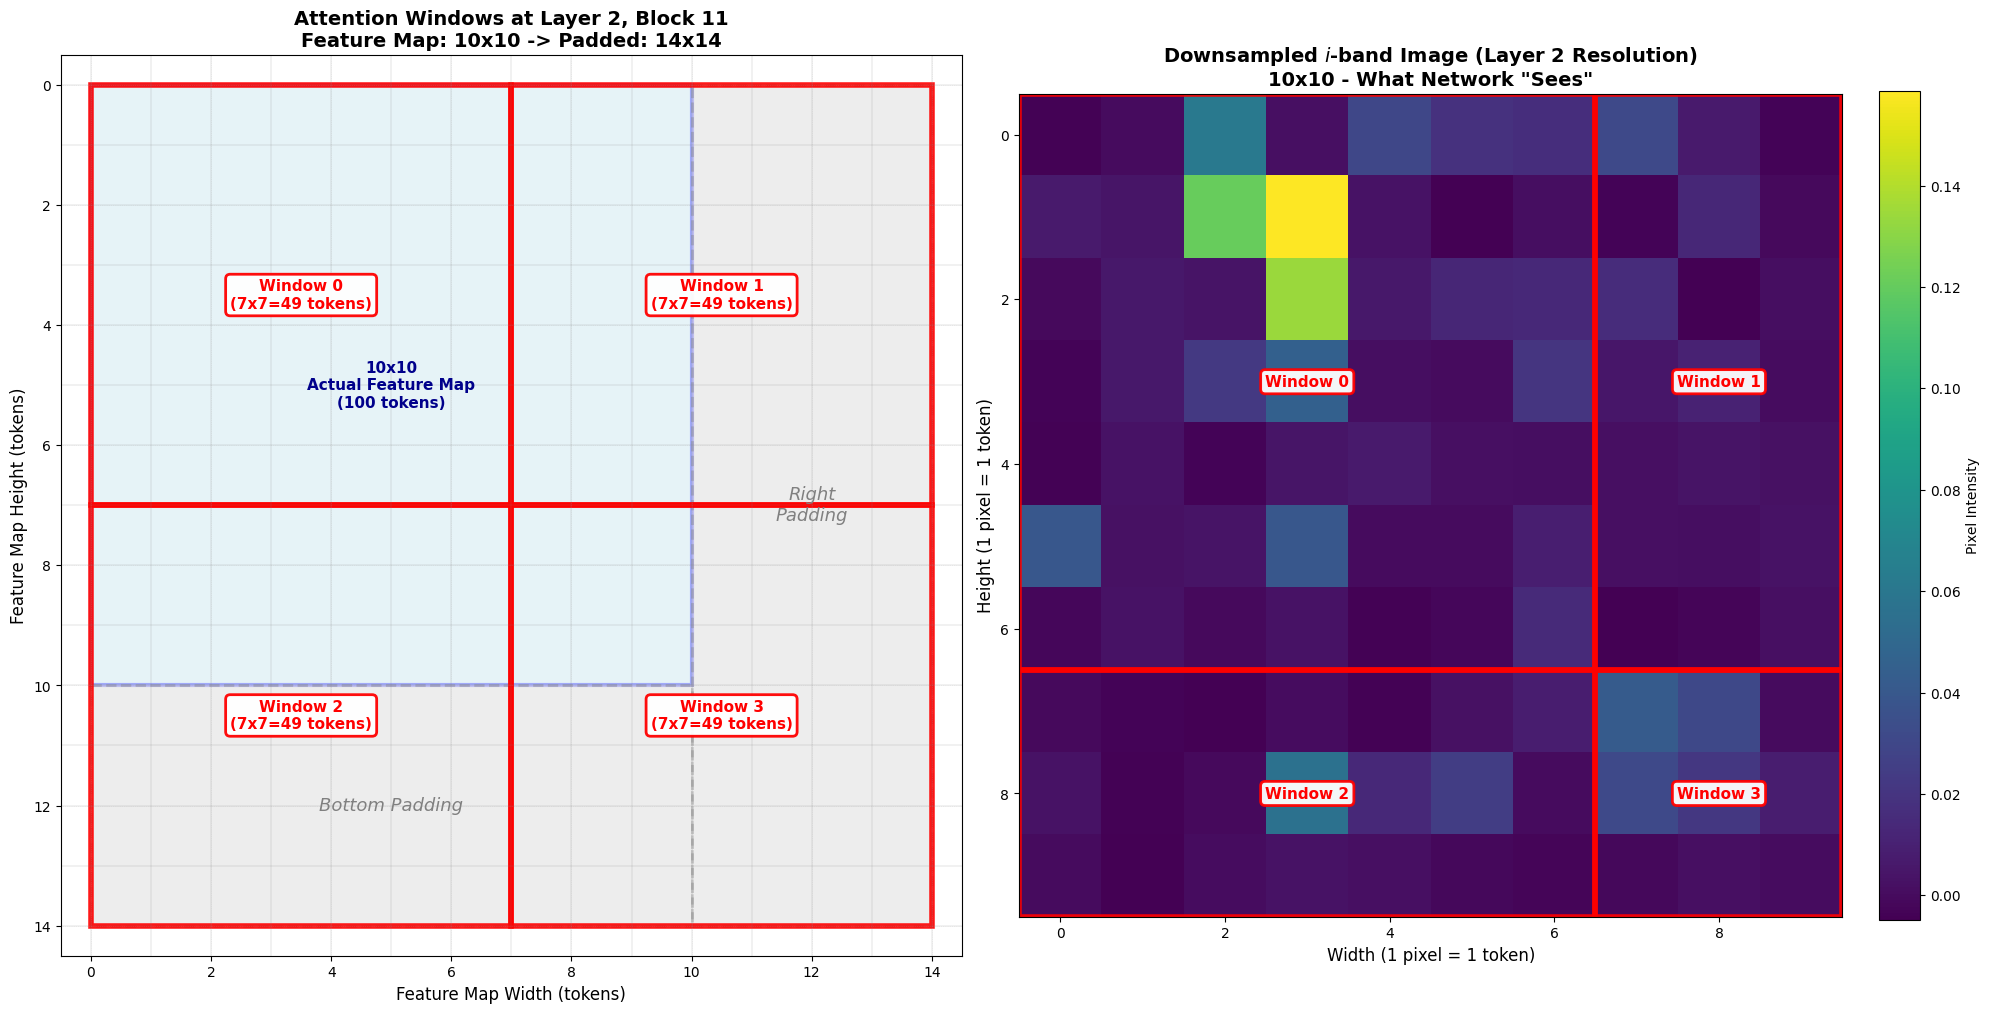

In [ ]:
import torch.nn.functional as F

# prepping the image data
padded_size = cfg.model.backbone.square_pad
downsample_factor = padded_size // feature_h
print("Downsample factor (padded_size // feature_h):", downsample_factor)
img_h, img_w = sample['image'].shape[1], sample['image'].shape[2]
img_data_iband = sample['image'][3] # ugrizy
padded_img = np.zeros((padded_size, padded_size))
padded_img[0:img_h, 0:img_w] = img_data_iband
padded_tensor = torch.from_numpy(padded_img).unsqueeze(0).unsqueeze(0).float() # shape [B, C, H, W]
downsampled = F.avg_pool2d(padded_tensor, kernel_size=downsample_factor, stride=downsample_factor)
downsampled_img = downsampled.squeeze().numpy()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))
ax1.set_title(f'Attention Windows at Layer {layer_idx}, Block {block_idx}\n' +
             f'Feature Map: {feature_h}x{feature_w} -> Padded: {padded_h}x{padded_w}', 
              fontsize=14)
ax1.set_xlim(-0.5, padded_w + 0.5)
ax1.set_ylim(-0.5, padded_h + 0.5)
ax1.set_xlabel('Feature Map Width (tokens)', fontsize=12)
ax1.set_ylabel('Feature Map Height (tokens)', fontsize=12)
ax1.set_aspect('equal')
ax1.grid(True, alpha=0.3, linestyle=':', linewidth=0.5)

ax1.add_patch(Rectangle((0, 0), feature_w, feature_h, 
                        linewidth=3, edgecolor='blue', facecolor='lightblue', alpha=0.3))
ax1.text(feature_w/2, feature_h/2, f'{feature_h}x{feature_w}\nActual Feature Map\n({num_patches} tokens)', 
         ha='center', va='center', fontsize=11, color='darkblue')

# padding regions
if padded_h > feature_h:
    ax1.add_patch(Rectangle((0, feature_h), feature_w, padded_h - feature_h,
                           linewidth=2, edgecolor='gray', facecolor='lightgray', 
                           alpha=0.4, linestyle='--'))
    ax1.text(feature_w/2, feature_h + (padded_h - feature_h)/2, 'Bottom Padding',
            ha='center', va='center', fontsize=13, style='italic', color='gray')

if padded_w > feature_w:
    ax1.add_patch(Rectangle((feature_w, 0), padded_w - feature_w, padded_h,
                           linewidth=2, edgecolor='gray', facecolor='lightgray', 
                           alpha=0.4, linestyle='--'))
    ax1.text(feature_w + (padded_w - feature_w)/2, padded_h/2, 'Right\nPadding',
            ha='center', va='center', fontsize=13, style='italic', color='gray')

# attention windows on the padded feature map
for i in range(num_windows_h):
    for j in range(num_windows_w):
        y_start = i * window_size
        x_start = j * window_size
        
        rect = Rectangle((x_start, y_start), window_size, window_size, 
                        linewidth=4, edgecolor='red', facecolor='none', 
                        linestyle='-', alpha=0.9)
        ax1.add_patch(rect)

        ax1.text(x_start + window_size/2, y_start + window_size/2, 
                f'Window {i*num_windows_w + j}\n({window_size}x{window_size}={window_size*window_size} tokens)',
                color='red', fontsize=11,
                ha='center', va='center',
                bbox=dict(boxstyle='round', facecolor='white', edgecolor='red', 
                         linewidth=2, alpha=0.95))

# grid lines for individual tokens
for i in range(padded_h + 1):
    ax1.axhline(i, color='gray', linewidth=0.3, alpha=0.5)
for j in range(padded_w + 1):
    ax1.axvline(j, color='gray', linewidth=0.3, alpha=0.5)
ax1.invert_yaxis()

# downsampled img
ax2.imshow(downsampled_img, origin='upper', cmap='viridis')
ax2.set_title(f'Downsampled $i$-band Image (Layer {layer_idx} Resolution)\n' +
              f'{feature_h}x{feature_w} - What Network "Sees"', 
              fontsize=14)
ax2.set_xlabel('Width (1 pixel = 1 token)', fontsize=12)
ax2.set_ylabel('Height (1 pixel = 1 token)', fontsize=12)
fig.colorbar(ax2.images[0], ax=ax2, label='Pixel Intensity', fraction=0.046, pad=0.04)

for i in range(num_windows_h):
    for j in range(num_windows_w):
        y_start = i * window_size
        x_start = j * window_size
        
        if x_start < feature_w and y_start < feature_h:
            x_end = min(x_start + window_size, feature_w)
            y_end = min(y_start + window_size, feature_h)
            width = x_end - x_start
            height = y_end - y_start
            # print(x_start, y_start, width, height)
            rect = Rectangle((x_start - 0.5, y_start - 0.5), width, height,
                            linewidth=4, edgecolor='red', facecolor='none', 
                            linestyle='-', alpha=0.9)
            ax2.add_patch(rect)
        
            ax2.text(x_start - 0.5 + width/2, y_start - 0.5 + height/2, 
                    f'Window {i*num_windows_w + j}',
                    color='red', fontsize=11,
                    ha='center', va='center',
                    bbox=dict(boxstyle='round', facecolor='white', edgecolor='red', 
                             linewidth=2, alpha=0.95))

plt.tight_layout()

Ok, so what do these two plots actually mean?

The left plot is showing that the attention operates on a 10x10 feature map, NOT the original image. The map is padded to 14x14 to accommodate a 2x2 grid of 7x7 windows. Each window contains 49 tokens (7x7) that compute self-attention within that window. It mainly tells us about the structure of the feature map where attention is computed.

The right plot is a **low-res version** of our original LSST image, specifically downsampled to match the resolution of the feature map at this layer of the Swin Transformer. It's a visual representation of the spatial info the model is actually processing at this stage. The bright yellow areas correspond to regions in the original image with high average pixel intensity (which makes sense if you look at our original image with the cluster of 3 galaxies). 

Each pixel in that `10x10` grid represents the **average pixel intensity** of a corresponding `16x16` block from the original, padded `160x160` image. For example, the single bright yellow pixel at position (row=1, column=3) is the numerical average of all `16 * 16 = 256` pixel values from that specific block in the original input image. This essentially shows us the actual image data that each token represents. 

So, the token at coordinate (x=2, y=1) on the left is a feature vector inside the model. The pixel at (x=2, y=1) on the right shows us the average brightness of the image region that this token is responsible for.

## Grabbing the Attention

In [ ]:
# dict to store captured values from hooks
attention_outputs = {}
def create_hook(name):
    """Factory function to create hooks that capture outputs"""
    def hook(module, input, output):
        # output in our dict
        attention_outputs[name] = output.detach().cpu() if isinstance(output, torch.Tensor) else output
        print(f"Captured {name}: type={type(output)}")
        if isinstance(output, torch.Tensor):
            print(f"   Shape: {output.shape}, dtype: {output.dtype}, range: [{output.min():.3f}, {output.max():.3f}]")
    return hook

# Load model and get a batch (using your existing code)
print("Setting up hooks...")

# registering hooks on diff parts of the WindowAttention module (found based on get_swin_architecture.py)
hooks = []
hooks.append(target_block.attn.qkv.register_forward_hook(create_hook('qkv_output')))
hooks.append(target_block.attn.attn_drop.register_forward_hook(create_hook('attn_drop_output')))
hooks.append(target_block.attn.proj.register_forward_hook(create_hook('proj_output')))
hooks.append(target_block.attn.proj_drop.register_forward_hook(create_hook('proj_drop_output')))
hooks.append(target_block.attn.softmax.register_forward_hook(create_hook('softmax_output')))
hooks.append(target_block.attn.register_forward_hook(create_hook('attn_full_output')))

print(f"Registered {len(hooks)} hooks on layers.{layer_idx}.blocks.{block_idx}.attn")

# forward pass with a single sample
print("\n Running forward pass...")
model.eval()
with torch.no_grad():
    # forward pass through just the backbone
    _ = backbone(input_tensor)

print("\nCaptured outputs:")
print("="*60)

for name, output in attention_outputs.items():
    print(f"\n {name}:")
    if isinstance(output, torch.Tensor):
        print(f"   Shape: {output.shape}")
        print(f"   Dtype: {output.dtype}")
        print(f"   Min: {output.min().item():.6f}")
        print(f"   Max: {output.max().item():.6f}")
        print(f"   Mean: {output.mean().item():.6f}")
        print(f"   Std: {output.std().item():.6f}")
        
        if torch.isnan(output).any():
            print(f"   Contains NaN values!")
        if torch.isinf(output).any():
            print(f"   Contains Inf values!")
    else:
        print(f"   Type: {type(output)}")

# cleanup hooks
print("\nRemoving hooks...")
for hook in hooks:
    hook.remove()
print("Hooks removed!")

Setting up hooks...
Registered 6 hooks on layers.2.blocks.11.attn

 Running forward pass...
Captured qkv_output: type=<class 'torch.Tensor'>
   Shape: torch.Size([4, 49, 1536]), dtype: torch.float32, range: [-1.971, 1.967]
Captured softmax_output: type=<class 'torch.Tensor'>
   Shape: torch.Size([4, 16, 49, 49]), dtype: torch.float32, range: [0.000, 0.169]
Captured attn_drop_output: type=<class 'torch.Tensor'>
   Shape: torch.Size([4, 16, 49, 49]), dtype: torch.float32, range: [0.000, 0.169]
Captured proj_output: type=<class 'torch.Tensor'>
   Shape: torch.Size([4, 49, 512]), dtype: torch.float32, range: [-0.527, 0.442]
Captured proj_drop_output: type=<class 'torch.Tensor'>
   Shape: torch.Size([4, 49, 512]), dtype: torch.float32, range: [-0.527, 0.442]
Captured attn_full_output: type=<class 'torch.Tensor'>
   Shape: torch.Size([4, 49, 512]), dtype: torch.float32, range: [-0.527, 0.442]

Captured outputs:

 qkv_output:
   Shape: torch.Size([4, 49, 1536])
   Dtype: torch.float32
   Min:

All the attention tensors `shape[0]` should be `num_imgs_in_batch * num_windows` and we see 4 (`1 img * 4 windows`)! This is what we wanted to see so that's great!

Ok, so which module do we actually want? To understand which one we need, let's look into the data flow of this block:

1.  An input tensor of tokens goes into `block.norm1` (LayerNorm).
2.  The result goes into the **entire `block.attn` module**.
3.  **Inside `block.attn`**:
    * The `qkv` layer runs creating Query, Key, Value matrices from the normalized input.
    * `attn = Q @ K ^ T / sqrt(d)` produces the `[..., 49, 49]` attention matrix.
    * The `softmax` layer normalizes the attention weights.
    * This matrix passes through **`attn_drop`**. (This is our last chance to see it!)
    * This matrix is then immediately multiplied by the Value matrix (`V`) and passed to the **`proj` and `proj_drop` layers** whose output has a different shape (e.g., `[4, 49, 512]`) becoming the final result of the `block.attn` module.
4.  This final result is then passed to `block.drop_path`. Added back to the original input (residual connection) and that output goes into `block.norm2` (LayerNorm).

Thus, we have to grab the attention from `attn_drop`!

In [ ]:
attn_weights = attention_outputs['attn_drop_output']
print(f"Attention weights statistics:")
print(f"   Shape: {attn_weights.shape}")  # [num_imgs_in_batch * num_windows, num_heads, num_tokens, num_tokens]
print(f"   Sum along last dim (should be 1.0): {attn_weights.sum(dim=-1).mean():.6f}")

Attention weights statistics:
   Shape: torch.Size([4, 16, 49, 49])
   Sum along last dim (should be 1.0): 1.000000


## Understanding the Attention Tensor Shape

Let's break down the `attn_drop_output` tensor shape in detail. We already explained the first dimension (0-indexed) above. But, here is the shape we expect:

**Shape**: `[num_windows × batch_size, num_heads, num_tokens_per_window, num_tokens_per_window]`

*Dimension 2: num_heads = 16*
- This is Layer 2 in the Swin Transformer, which has **16 attention heads** (from config: `num_heads=[4, 8, 16, 32]` for layers 0-3)
- Each head learns different attention patterns
- Multi-head attention allows the model to attend to different aspects simultaneously

*Dimensions 3 & 4: num_tokens_per_window = 49 (7×7)*
- Each window is 7×7 tokens = 49 tokens
- The attention matrix is 49×49, showing how each token attends to every other token within the same window
- **Rows (dim 3)**: Query positions - "which token is asking"
- **Columns (dim 4)**: Key positions - "which tokens it's looking at"
- Each row sums to ~1.0 (softmax normalization)

So, this shape `[4, 16, 49, 49]` means:
- We have 4 independent attention computations (one per window)
- Each window has 16 attention heads computing different patterns
- Within each head, every token (49 total) computes attention scores to all other tokens in its window
- The result is a set of attention weights determining how info flows between tokens

## Plotting the Raw Attention

Let's take a look at the attention of window 0 for head 11 so `attn_weights[0, 11]`.

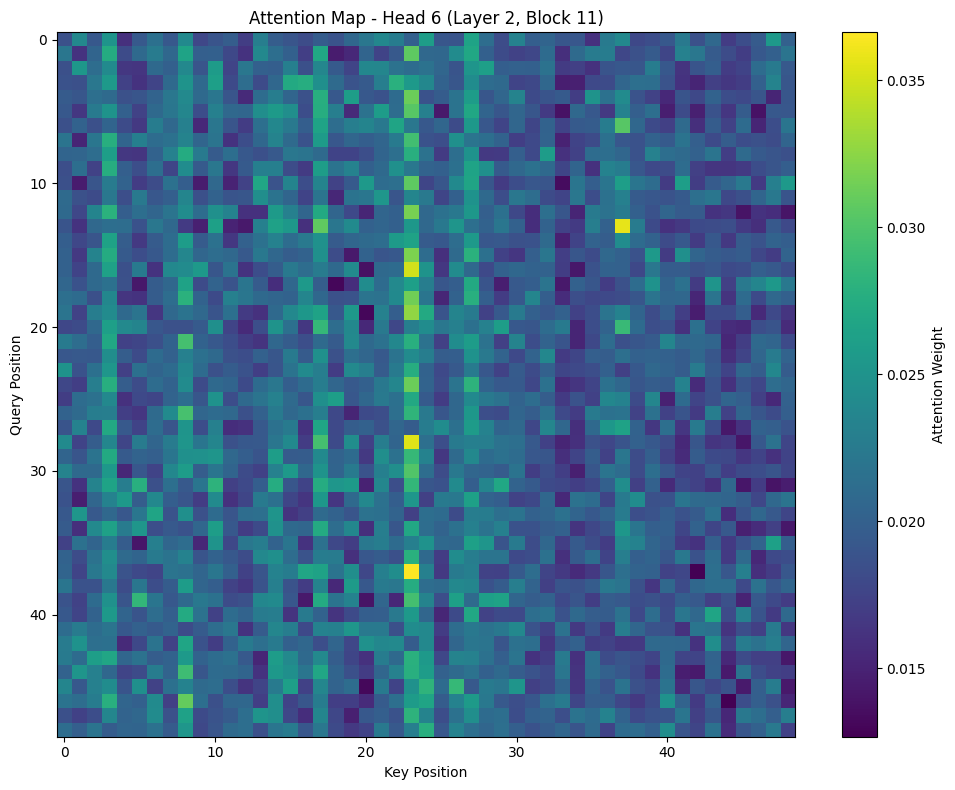

In [ ]:
window = 0
head_num = 6
head = attn_weights[window, head_num].numpy()
pd.DataFrame(head).describe()
plt.figure(figsize=(10, 8))
plt.imshow(head, cmap='viridis', aspect='auto')
plt.colorbar(label='Attention Weight')
plt.title(f'Attention Map - Head {head_num} (Layer {layer_idx}, Block {block_idx})')
plt.xlabel('Key Position')
plt.ylabel('Query Position')
plt.tight_layout()

## Interpreting the Raw Attention

change this to cluster of 3 galaxies img /u/yse2/

In the heatmap above, each cell *(i, j)* represents how much the token at position *i* (query) attends to the token at position *j* (key) within this 7×7 window. **Brighter colors** indicate **stronger attention** weights. So, in the above case for the last head for Layer 2 Block 11 (for `lsst_data/truth/54.40_-40.1/c42_54.40_-40.1.npy`), tokens at positions 20-30 (middle of 7x7 window) show higher attention values across most query positions. The vertical stripes indicate certain key positions receive attention from many different query positions.

<!-- tokens at positions 42-48 (right side of 7x7 window) show consistently higher attention values across all query positions. The vertical stripes indicate certain key positions receive attention from many different query positions.  -->

**Physical Meaning:**
As we are at Layer 2, Block 11, keep in mind that the original image has been heavily downsampled by this point. 
- **Position 20-30 (Middle)**
The brightness here suggests this region contains features that are *IMPORTANT* across the entire window! There's likely an a source (e.g. the group of 3 galaxies) or a bright/distinctive feature in this part of the image. The attention mechanism has learned that tokens should "look at" this region regardless of their own position, suggesting:
  - A bright source that provides context to surrounding regions
  - Edge features that help define object boundaries
  - High-contrast features useful for classification
- **Vertical Stripes**
These key positions (columns) act as "anchor points" or "reference features" that multiple tokens query for information. These could be 
  - Centers of detected sources (galaxies/stars)
  - Regions with distinctive spectral signatures across six bands
  - Boundaries between sky background and sources
  - Locations where the model has learned to "gather context"

## Limitations Of Raw Attention

This shows WHERE the model looks, but NOT whether that attention is HELPFUL.
For example:
- The bright right edge might be noise or artifacts (bad)
- OR it might be a real galaxy/star the model correctly identifies (good)

We can't tell the difference with raw attention alone.

Let's do a sanity check of what the shapes of the inputs and outputs are. Since we set `model.backbone.square_pad = 160` and the inputs for Swin are usually `[B, H*W, C]`, we should expect to see the following:

| Layer | Input Tokens (H*W) | Spatial Resolution | Input Channels | Output Channels | Output Tokens |
|-------|--------------|-------------------|----------------|-----------------|----------|
| 0 | 1,600 | 40x40 | 128 | 128 | 1,600 |
| 1 | 400 | 20x20 | 256 | 256 | 400 |
| 2 | 100 | 10x10 | 512 | 512 | 100 |
| 3 | 25 | 5x5 | 1024 | 1024 | 25 |

In [ ]:
from detectron2.utils.events import EventStorage # need this for training mode forward pass
def layer_hook(layer_idx):
    def hook(module, input, output):
        print(f"Layer {layer_idx}: ")
        x = input[0]
        o = output[0]
        print(f" input shape: {x.shape}")  # [B, H*W, C] for Swin
        print(f" output shape: {o.shape}")  # [B, H*W, C] for Swin
    return hook

print("Clearing all existing hooks...")
for i in range(4):
    if len(backbone.layers[i]._forward_hooks) > 0:
        print(f"  Clearing {len(backbone.layers[i]._forward_hooks)} hooks from layer {i}")
        backbone.layers[i]._forward_hooks.clear()

hook_handles = []
for layer_idx in range(4):
    shape_handle = backbone.layers[layer_idx].register_forward_hook(layer_hook(layer_idx))
    hook_handles.append(shape_handle)

print(f"Registered {len(hook_handles)} hooks on all layers")
# now do a forward pass
print(f"Forward pass with grad tracking...\n")
try:
    with EventStorage():
        loss_dict = model([sample])
        print("\nForward pass complete")
finally:
    print("\nCleaning up hooks...")
    for hook in hook_handles:
        hook.remove()
    hook_handles.clear()
    for i in range(4):
        print(f"Hooks remaining for Layer {layer_idx}: {len(backbone.layers[layer_idx]._forward_hooks)}")

Clearing all existing hooks...
Registered 4 hooks on all layers
Forward pass with grad tracking...

Layer 0: 
 input shape: torch.Size([1, 1600, 128])
 output shape: torch.Size([1, 1600, 128])
Layer 1: 
 input shape: torch.Size([1, 400, 256])
 output shape: torch.Size([1, 400, 256])
Layer 2: 
 input shape: torch.Size([1, 100, 512])
 output shape: torch.Size([1, 100, 512])
Layer 3: 
 input shape: torch.Size([1, 25, 1024])
 output shape: torch.Size([1, 25, 1024])

Forward pass complete

Cleaning up hooks...
Hooks remaining for Layer 3: 0
Hooks remaining for Layer 3: 0
Hooks remaining for Layer 3: 0
Hooks remaining for Layer 3: 0
